# 1. Numerical accuracy of multi-stage race solvers

This notebook tests an invariance every solver should satisfy: adding stage labels to a process without changing its parameters must leave its predictions unchanged. We compare choice/RT density estimates from the Laguerre, Centered, and Volterra solvers with analytic reference values across a test set, including cases with different stage divisions. A curve is wrong when its predicted density differs from the reference, even if it looks smooth.

We also test cases where parameters change between stages. In one such case, the changes are chosen so we can still calculate the correct answer for comparison.

This extends [the original validation notebook](race_model_validation.ipynb). The Volterra formulation is motivated by **Appendix B** of the following preprint:

Malte Lüken, Stefan T. Radev, Lourens Waldorp, and Andrew Heathcote (2026). *[Neural Racing Accumulator Model Estimation With Lightweight Monotonic Flows](https://doi.org/10.31234/osf.io/bfsgr_v1).* Preprint, version 1. 

Appendix B presents a Volterra integral equation for the first-passage density and a numerical reference method. Here we adapt that formulation to piecewise drift, noise, and boundary slopes using cumulative-variance time. 

In [1]:
from pathlib import Path
import os
import sys
import tempfile
from time import perf_counter

root = next(p for p in [Path.cwd(), *Path.cwd().parents]
            if (p / "setup.py").exists() and (p / "ssms").exists())
folder = root / "notebooks/volterra_accuracy"
sys.path[:0] = [str(root / "notebooks"), str(root)]
os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "race-notebook-mpl"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from volterra_accuracy.experiment_helpers import (
    METHODS, analytic_cases, build_model, parameter_table, time_grid,
    exact_marginals, race_density, probability_bins, accuracy_row,
    specifications, sample_runner, sample_race, compare_sample,
    empirical_cdf, wilson_interval, refine_reference, evidence_conditions,
    split_without_changing, batch_log_likelihood, save_results,
)

pd.set_option("display.max_rows", 14)
pd.set_option("display.max_columns", 12)
plt.rcParams.update({"figure.figsize": (10, 3.8), "axes.spines.top": False,
                     "axes.spines.right": False, "font.size": 10})

### Model setup and validation cases

We investigate how three solvers perform when we add stage divisions, shorten a stage, change drift, start near a boundary, or vary parameters between stages. Two independent runners race to their upper boundaries for up to 2 time units; drift, noise, and boundary slope stay constant within each stage. The table below gives the baseline parameters.

- Runner 0's first stage starts at time 0 and lasts 0.02 rather than 0.22 time units, with unchanged parameters (short first).
- Runner 0's second stage starts at time 0.22 and lasts 0.0001 rather than 0.35 time units, with unchanged parameters (short middle).
- Runner 0 has negative drift relative to its boundary, so its mean distance below the boundary increases (negative drift).
- Runner 0 starts only 0.05 below its boundary, creating a sharp early crossing peak (near boundary).
- A separate model varies drift, noise, and boundary slopes while preserving an exact solution in cumulative-variance time (varying parameters).


In [2]:
cases = analytic_cases()
orders = [10, 20, 40, 80]
methods = ["Laguerre", "Centered", "Volterra"]
display(parameter_table(cases["5 stages"]))
print("Cases:", ", ".join(cases))
print("Targets: density error < 1e-6; CDF, bin and mass errors < 1e-7.")
case_parameters = pd.concat([parameter_table(s).assign(case=name) for name, s in cases.items()], ignore_index=True)
display(pd.DataFrame([dict(case=name, runner_0_breaks=list(s[0]["breaks"]), runner_0_start=s[0].get("x0", 0)) for name, s in cases.items()]))

Cases: 1 stage, 5 stages, 10 stages, 20 stages, Short first, Short middle, Negative drift, Near boundary, Varying parameters
Targets: density error < 1e-6; CDF, bin and mass errors < 1e-7.


,runner,stage,start,duration,mu,sigma,boundary_slope,initial_boundary,x0
0,0,1,0.00,0.22,0.55,0.80,-0.12,1.45,0.10
1,0,2,0.22,0.35,0.55,0.80,-0.12,1.45,0.10
2,0,3,0.57,0.38,0.55,0.80,-0.12,1.45,0.10
3,0,4,0.95,0.47,0.55,0.80,-0.12,1.45,0.10
4,0,5,1.42,0.58,0.55,0.80,-0.12,1.45,0.10
5,1,1,0.00,0.31,0.30,0.95,0.06,1.30,-0.05
6,1,2,0.31,0.35,0.30,0.95,0.06,1.30,-0.05
7,1,3,0.66,0.42,0.30,0.95,0.06,1.30,-0.05
8,1,4,1.08,0.53,0.30,0.95,0.06,1.30,-0.05
9,1,5,1.61,0.39,0.30,0.95,0.06,1.30,-0.05


,case,runner_0_breaks,runner_0_start
0,1 stage,"[0.0, 2.0]",0.1
1,5 stages,"[0, 0.22, 0.57, 0.95, 1.42, 2]",0.1
2,10 stages,"[0.0, 0.2, 0.4, 0.6000000000000001, 0.8, 1.0, ...",0.1
3,20 stages,"[0.0, 0.1, 0.2, 0.30000000000000004, 0.4, 0.5,...",0.1
4,Short first,"[0, 0.02, 0.57, 0.95, 1.42, 2]",0.1
5,Short middle,"[0, 0.22, 0.2201, 0.95, 1.42, 2]",0.1
6,Negative drift,"[0, 0.22, 0.57, 0.95, 1.42, 2]",0.1
7,Near boundary,"[0, 0.22, 0.57, 0.95, 1.42, 2]",1.4
8,Varying parameters,"[0, 0.18, 0.54, 0.87, 1.31, 1.8]",0.0


### Parameters change, but we can still calculate the reference

In this case, drift, noise, and boundary slope change at each stage. The full values are in the table below. We choose them by $\mu_k=b_k+v\sigma_k^2$, keeping $v=(\mu_k-b_k)/\sigma_k^2$ fixed for each runner (0.6 for runner 0 and -0.2 for runner 1).

This coordination is what gives us an exact comparison: after accounting for boundary motion and measuring time by accumulated noise, $V(t)=\int_0^t\sigma(s)^2\,ds$, each runner follows the same one-boundary process throughout the stages. Its CDF and density are therefore $F(t)=F_{\rm Wald}(V(t))$ and $f(t)=\sigma_k^2f_{\rm Wald}(V(t))$ in stage $k$. The solver’s results can be compared with these formulas even though the stage parameters differ. A noise change can make the density jump at a stage boundary, while the CDF stays continuous.

In [3]:
display(parameter_table(cases["Varying parameters"]))
# The ratio must be constant within each runner for this reference to apply.
for runner, spec in enumerate(cases["Varying parameters"]):
    ratio = (np.asarray(spec["mu"]) - spec["boundary_slopes"]) / np.asarray(spec["sigma"])**2
    print(f"Runner {runner}: drift in variance time = {ratio.round(4)}")

Runner 0: drift in variance time = [0.6 0.6 0.6 0.6 0.6]
Runner 1: drift in variance time = [-0.2 -0.2 -0.2 -0.2 -0.2]


,runner,stage,start,duration,mu,sigma,boundary_slope,initial_boundary,x0
0,0,1,0.00,0.18,0.3075,0.75,-0.03,1.35,0.00
1,0,2,0.18,0.36,0.4735,0.85,0.04,1.35,0.00
2,0,3,0.54,0.33,0.3040,0.80,-0.08,1.35,0.00
3,0,4,0.87,0.44,0.5060,0.90,0.02,1.35,0.00
4,0,5,1.31,0.49,0.2975,0.75,-0.04,1.35,0.00
5,1,1,0.00,0.31,-0.1245,0.85,0.02,1.38,-0.05
6,1,2,0.31,0.32,-0.1625,0.75,-0.05,1.38,-0.05
7,1,3,0.63,0.43,-0.1505,0.95,0.03,1.38,-0.05
8,1,4,1.06,0.40,-0.1980,0.80,-0.07,1.38,-0.05
9,1,5,1.46,0.34,-0.1520,0.90,0.01,1.38,-0.05


### Measure errors

For choice $i$, let $q_i(t)=f_i(t)\prod_{j\ne i}[1-F_j(t)]$. The reported errors are $E_f=\max_{t,i}|\hat q_i-q_i|$, $E_F=\max_{t,i}|\hat F_i-F_i|$, and $E_{\rm mass}=|\sum_{b,i}\hat P_{bi}+\hat P_{\rm omit}-1|$. The plotted density errors include samples at stage boundaries and just before and after them. RT-bin probabilities are integrated separately across each parameter change.

`meets_targets` requires $E_f<10^{-6}$; CDF, bin, and mass errors $<10^{-7}$; the largest sampled CDF drop $<10^{-10}$; and minimum runner density $>-10^{-10}$. Laguerre and Centered limit CDF values to the range 0–1; Volterra leaves its raw results unchanged, so small interpolation errors remain visible. Here, `order` means polynomial degree for Volterra and quadrature-node count for Laguerre and Centered.

The plots below show the density criterion for every analytic case. The pass/fail table applies all six checks.


In [4]:
rows = []
for name, specs in cases.items():
    case_orders = orders if name == "5 stages" else [20, 40, 80]
    for method in methods:
        for order in case_orders:
            rows.append(accuracy_row(name, specs, method, order))
# A steep early peak deserves a targeted refinement, not a hidden parameter change.
for order in [160, 240]:
    rows.append(accuracy_row("Near boundary", cases["Near boundary"], "Volterra", order))
errors = pd.DataFrame(rows)
display(errors.query("`case` == '5 stages'")[["method", "order", "max_density_error", "max_cdf_error", "mass_error", "meets_targets"]])
display(errors.query("order == 80").pivot(index="case", columns="method", values="max_density_error"))
display(errors.query("order == 80").pivot(index="case", columns="method", values="meets_targets"))

,method,order,max_density_error,max_cdf_error,mass_error,meets_targets
9,Laguerre,10,8.895372e-03,7.543946e-03,2.220446e-16,False
10,Laguerre,20,2.138397e-04,5.412297e-05,2.220446e-16,False
11,Laguerre,40,4.049305e-07,5.356187e-08,0.000000e+00,True
12,Laguerre,80,1.025935e-11,3.091971e-13,2.220446e-16,True
13,Centered,10,7.035874e-03,2.410767e-03,2.220446e-16,False
14,Centered,20,7.023368e-08,7.527187e-09,0.000000e+00,True
15,Centered,40,6.661338e-16,1.110223e-15,2.220446e-16,True
16,Centered,80,1.054712e-15,1.554312e-15,2.220446e-16,True
17,Volterra,10,2.556666e-04,4.369434e-06,2.442491e-15,False
18,Volterra,20,1.278350e-06,1.005730e-08,0.000000e+00,False


method,Centered,Laguerre,Volterra
case,,,
1 stage,3.330669e-16,3.330669e-16,1.768755e-11
10 stages,1.887379e-15,5.876329e-10,4.440892e-16
20 stages,3.885781e-15,3.331950e-06,5.551115e-16
5 stages,1.054712e-15,1.025935e-11,4.163336e-16
Near boundary,1.421085e-13,1.421085e-13,1.440620e-02
Negative drift,9.436896e-16,2.055842e-12,3.885781e-16
Short first,1.554312e-15,2.348783e-03,5.551115e-16
Short middle,9.794762e-01,2.948022e-01,4.163336e-16
Varying parameters,1.443290e-15,1.282833e-10,3.885781e-16


method,Centered,Laguerre,Volterra
case,,,
1 stage,True,True,True
10 stages,True,True,True
20 stages,True,False,True
5 stages,True,True,True
Near boundary,False,False,False
Negative drift,True,True,True
Short first,True,False,True
Short middle,False,False,True
Varying parameters,True,True,True


The second table reports `max_density_error` at order 80: the maximum absolute difference between the calculated and analytic density over the tested times and choices; smaller is better. The third table uses the same cases and methods, but `True` means **all six** accuracy and validity checks pass, so a small density error alone does not guarantee a pass.

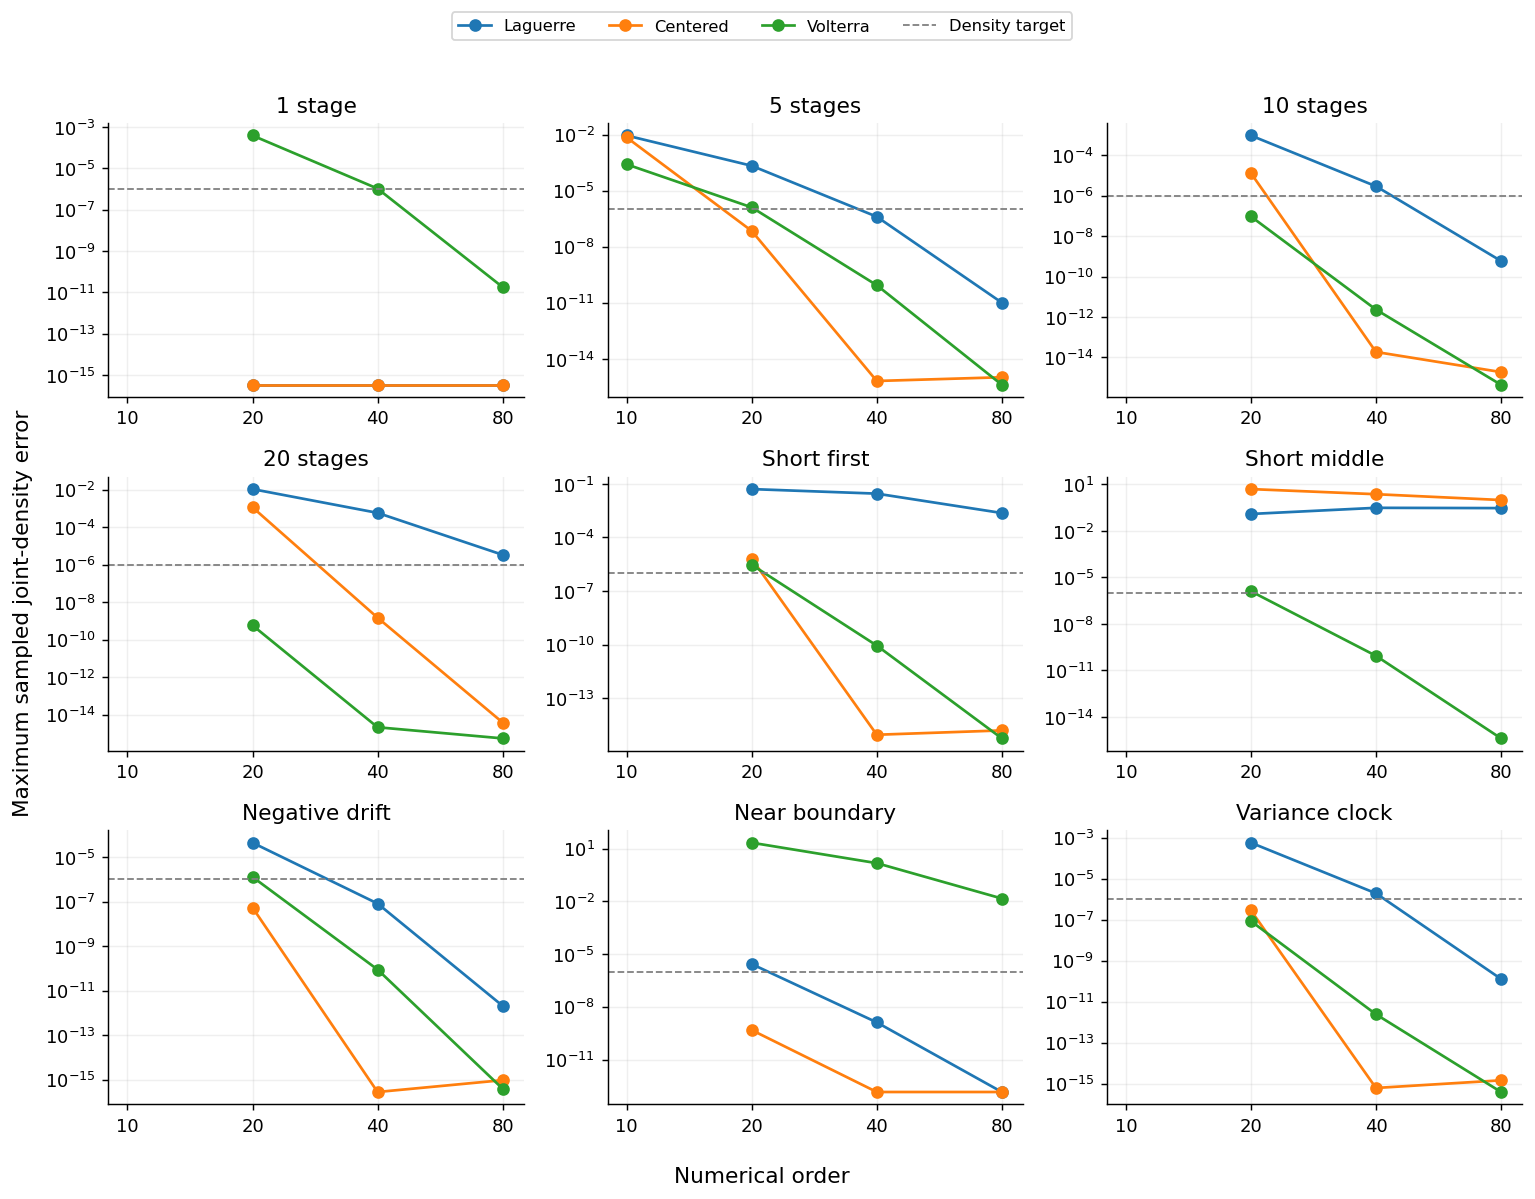

In [5]:
fig, axes = plt.subplots(3, 3, figsize=(12, 9))
for ax, case in zip(axes.flat, cases):
    for method in methods:
        table = errors[(errors["case"] == case) & (errors.method == method) & (errors.order <= 80)]
        ax.loglog(table.order, np.maximum(table.max_density_error, 1e-17), "o-", label=method)
    ax.axhline(1e-6, color="grey", ls="--", lw=1, label="Density target")
    ax.set_xscale("log", base=2)
    ax.set_xlim(9, 90)
    ax.set_xticks([10, 20, 40, 80], labels=["10", "20", "40", "80"])
    ax.set_title(case)
    ax.grid(True, which="both", alpha=.2)
fig.supxlabel("Numerical order")
fig.supylabel("Maximum sampled joint-density error")
fig.legend(*axes.flat[0].get_legend_handles_labels(), loc="upper center", ncol=4,
           bbox_to_anchor=(.5, 1.02), fontsize=9)
fig.tight_layout(rect=(0, 0, 1, .96))
plt.show()


Across the nine analytic cases, Volterra order 80 meets the plotted density target except in the near-boundary case.

### Check a stage transition with Volterra

The left panel compares order-80 Volterra choice/RT densities with the analytic reference for the varying-parameters case; the right panel shows their absolute errors around the first change at time 0.18, where noise changes.


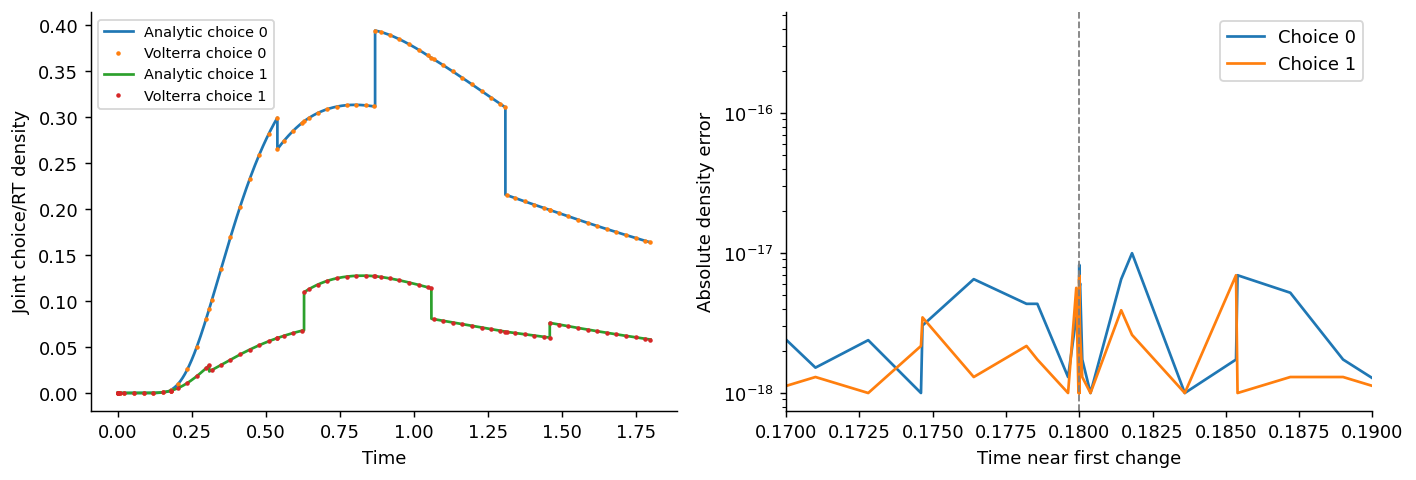

In [6]:
specs = cases["Varying parameters"]
grid = time_grid(specs)
truth = race_density(*exact_marginals(specs, grid))
model = build_model(specs, order=80)
predicted = race_density(*model.marginals(grid))
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
for runner in range(2):
    axes[0].plot(grid, truth[:, runner], label=f"Analytic choice {runner}")
    axes[0].plot(grid[::18], predicted[::18, runner], ".", ms=3, label=f"Volterra choice {runner}")
    axes[1].semilogy(grid, np.maximum(abs(predicted[:, runner]-truth[:, runner]), 1e-18), label=f"Choice {runner}")
axes[0].set(xlabel="Time", ylabel="Joint choice/RT density")
axes[1].set(xlim=(.17, .19), xlabel="Time near first change", ylabel="Absolute density error")
axes[1].axvline(.18, color="grey", ls="--", lw=1)
axes[0].legend(fontsize=8)
axes[1].legend()
fig.tight_layout()
plt.show()


Left panel: Volterra follows the analytic choice/RT curves, including their density jumps.

Right panel: The Volterra error around time 0.18 stays near floating-point precision.

At every exact interior stage change, both the analytic reference and Volterra evaluation use the parameter values from the stage on the left. For example, choice 0 density at time 0.18 is about 0.002561 using the left stage, while just after 0.18 it is about 0.003290 using the next stage.

### Check how calculation settings affect the result

For this changing-parameter case, we do not know the exact answer. So we adjust one calculation setting at a time: Volterra interpolation order, the tolerance for its history integral, or the order used to integrate response-time bins. The table shows how much the results move. Small changes suggest stability, but they are not measurements of the true error.

In [7]:
specs = specifications("B")
grid = time_grid(specs)
base = build_model(specs, order=80)
base_f, base_F = base.marginals(grid)
_, base_bins, base_omission = probability_bins(specs, base, order=48)
sensitivity_rows = []
for label, candidate, bin_order in [
    ("Interpolation: 80 to 120", build_model(specs, order=120), 48),
    ("History tolerance: 1e-10/1e-8 to 1e-12/1e-10", build_model(specs, order=80, passage_atol=1e-12, passage_rtol=1e-10), 48),
    ("RT integration: 48 to 96", base, 96),
]:
    f, F = candidate.marginals(grid)
    _, bins, omission = probability_bins(specs, candidate, order=bin_order)
    sensitivity_rows.append(dict(check=label, density_change=float(abs(f-base_f).max()),
                                 cdf_change=float(abs(F-base_F).max()),
                                 bin_change=float(abs(bins-base_bins).max()),
                                 omission_change=abs(omission-base_omission)))
sensitivity = pd.DataFrame(sensitivity_rows)
display(sensitivity)

,check,density_change,cdf_change,bin_change,omission_change
0,Interpolation: 80 to 120,6.439294e-14,7.771561e-16,4.510281e-17,7.771561e-16
1,History tolerance: 1e-10/1e-8 to 1e-12/1e-10,4.207745e-14,1.321165e-14,2.116363e-15,9.880985e-15
2,RT integration: 48 to 96,0.000000e+00,0.000000e+00,7.632783e-17,0.000000e+00


Each “change” shows how much a result moves when we alter one calculation setting from the baseline Volterra run (order 80, history tolerance `1e-10/1e-8`, bin-integration order 48). `density_change` and `cdf_change` are the biggest differences in any runner's density or CDF over the checked times; `bin_change` is the biggest difference in a choice-and-time-bin probability, and `omission_change` is the difference in the chance of no response by the deadline. “History tolerance” controls how precisely the solver integrates the effects of earlier stages: its two numbers are the absolute and relative error goals, tightened here to `1e-12/1e-10`.

### A hard case: starting near the boundary

In the **Near boundary** case, runner 0 starts at 1.40, just 0.05 below its initial boundary of 1.45. This creates a sharp burst of early responses, so we check whether higher numerical orders resolve the peak and keep negative density values visible as signs of numerical error.

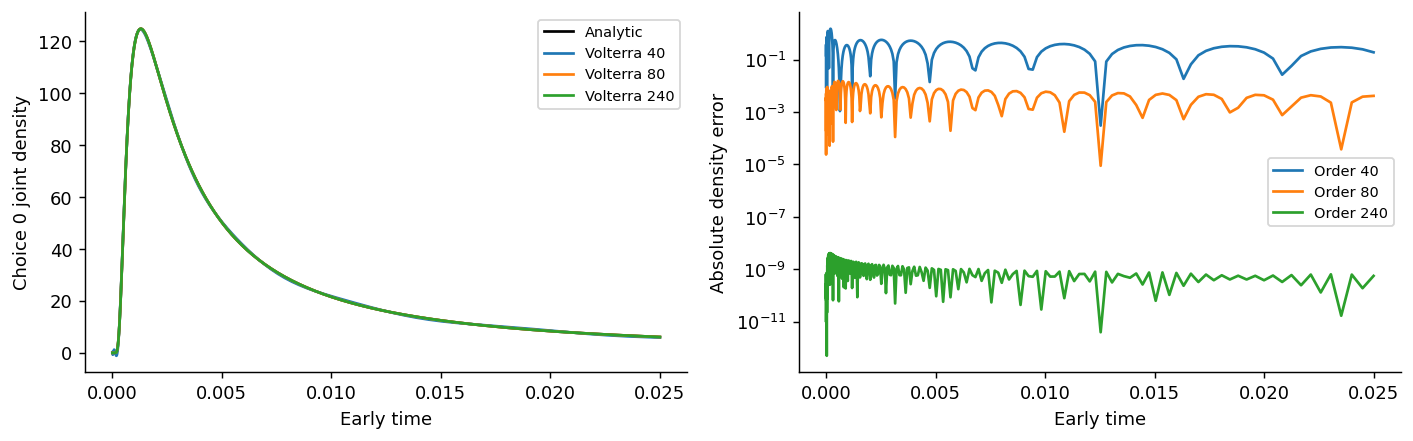

In [8]:
specs = cases["Near boundary"]
early = np.geomspace(1e-6, .025, 500)
truth = race_density(*exact_marginals(specs, early))[:, 0]
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
axes[0].plot(early, truth, color="black", label="Analytic")
for order in [40, 80, 240]:
    model = build_model(specs, order=order)
    predicted = race_density(*model.marginals(early))[:, 0]
    axes[0].plot(early, predicted, label=f"Volterra {order}")
    axes[1].semilogy(early, np.maximum(abs(predicted-truth), 1e-16), label=f"Order {order}")
axes[0].set(xlabel="Early time", ylabel="Choice 0 joint density")
axes[1].set(xlabel="Early time", ylabel="Absolute density error")
for ax in axes:
    ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

The plots check 500 time points from 0.000001 to 0.025 seconds to examine the sharp early peak. The validation table checks 1,337 points across 0–2 seconds, but only 101 fall in that same early interval. At order 80, the plot grid finds a maximum density error of about 0.0155; the **Near boundary / Volterra / order 80** row in the next table gives `1.440620e-02` (about 0.0144) because it checks fewer points near the peak.

In [9]:
near_boundary = errors[(errors["case"] == "Near boundary") & (errors.method == "Volterra")]
display(near_boundary[["order", "max_density_error", "max_cdf_error", "min_density", "largest_cdf_drop"]])
selected = errors[(errors.method == "Volterra") & (errors.order == 80)]
print(f"Volterra order 80 met all declared checks in {selected.meets_targets.sum()} of {len(selected)} analytic cases.")
print("Cases needing attention:", selected.loc[~selected.meets_targets, "case"].tolist())
assert np.isfinite(errors.select_dtypes(include="number").to_numpy()).all()
expected = ["5 stages", "Short first", "Short middle", "Negative drift", "Varying parameters"]
assert selected.set_index("case").loc[expected, "meets_targets"].all()
output = save_results("01_accuracy", {"errors": errors, "sensitivity": sensitivity, "all_case_parameters": case_parameters,
                       "baseline_parameters": parameter_table(cases["5 stages"]),
                       "varying_parameters": parameter_table(cases["Varying parameters"])},
                      {"density_target": 1e-6, "probability_target": 1e-7,
                       "negative_density_tolerance": 1e-10, "relative_density_floor": 1e-5,
                       "main_orders": orders, "near_boundary_extra_orders": [160, 240],
                       "grid": "1001 uniform points + early log grid + exact/adjacent/offset breakpoints"})
print("Saved tables:", output.relative_to(root))

Volterra order 80 met all declared checks in 8 of 9 analytic cases.
Cases needing attention: ['Near boundary']
Saved tables: examples/example6_race_model/results/01_accuracy


,order,max_density_error,max_cdf_error,min_density,largest_cdf_drop
72,20,2.157687e+01,6.259899e-03,-5.783899e+00,4.986571e-05
73,40,1.481508e+00,5.623308e-04,-1.060351e+00,2.467630e-05
74,80,1.440620e-02,3.974092e-06,-8.197583e-03,5.942236e-08
84,160,6.437618e-06,2.460958e-10,-6.433299e-06,5.137657e-11
85,240,4.151451e-09,1.991740e-13,-6.509880e-10,3.885781e-15


### Keep the sharp first stage analytic

The first stage already has an exact one-boundary answer. Interpolating it adds error without adding information. Let $d=a_0-x_0$, $u=\sigma_0^2t$, and $v=(\mu_0-b_0)/\sigma_0^2$. Its density in variance time is

$$g_0(u)=\frac{d}{\sqrt{2\pi u^3}}\exp\!\left[-\frac{(d-vu)^2}{2u}\right],\qquad f_0(t)=\sigma_0^2g_0(\sigma_0^2t).$$

`AnalyticFirstVolterraAccumulator` uses this density and its analytic CDF throughout stage one. It also uses the exact density **inside later history integrals** and carries forward the exact first-stage crossing probability. Later stages keep the existing Volterra interpolation. The implementation is in `paper_method_prototypes.py`; `build_model(..., "Volterra analytic first")` selects it. The original backend remains available for comparison.

Before judging either solver, we must also check the integration used to measure total probability. A narrow peak can fool that check even when the supplied density is exact.

In [10]:
from copy import deepcopy

improved_method = "Volterra analytic first"
near_specs = cases["Near boundary"]
integration_models = {
    "Analytic reference": None,
    "Original Volterra 240": build_model(near_specs, "Volterra", 240),
    "Analytic first, order 80": build_model(near_specs, improved_method, 80),
}
integration_rows = []
for label, candidate in integration_models.items():
    for bin_order in [48, 96, 192, 384]:
        _, bins, omission = probability_bins(near_specs, candidate, order=bin_order)
        integration_rows.append(dict(method=label, bin_order=bin_order,
                                     mass_error=abs(bins.sum()+omission-1)))
integration_check = pd.DataFrame(integration_rows)
display(integration_check.pivot(index="bin_order", columns="method", values="mass_error"))
# 192 is used below; 384 is an independent refinement of that measurement.
assert integration_check.query("bin_order >= 192").mass_error.max() < 1e-9

method,"Analytic first, order 80",Analytic reference,Original Volterra 240
bin_order,,,
48,4.084961e-07,4.084961e-07,4.085021e-07
96,1.618272e-11,1.618261e-11,2.640155e-11
192,8.881784e-15,8.770762e-15,2.886580e-15
384,1.398881e-14,1.398881e-14,2.398082e-14


With bin-integration order 48, even the exact answer appears to miss the total-probability check by about $4.1\times10^{-7}$. Raising that order to 96 reduces the error to about $1.6\times10^{-11}$, showing that the probability calculation was too coarse. We use order 192 below and report it separately from Volterra's interpolation order.

,method,order,bin_order,max_density_error,max_cdf_error,max_bin_error,mass_error,min_density,largest_cdf_drop,meets_targets
0,Volterra,80,192,1.440620e-02,3.974092e-06,1.307766e-06,1.143530e-14,-8.197583e-03,5.942236e-08,False
1,Volterra,240,192,4.151451e-09,1.991740e-13,5.895284e-14,2.886580e-15,-6.509880e-10,3.885781e-15,False
2,Volterra analytic first,80,192,1.421085e-14,7.771561e-16,6.071532e-18,8.881784e-15,0.000000e+00,2.220446e-16,True


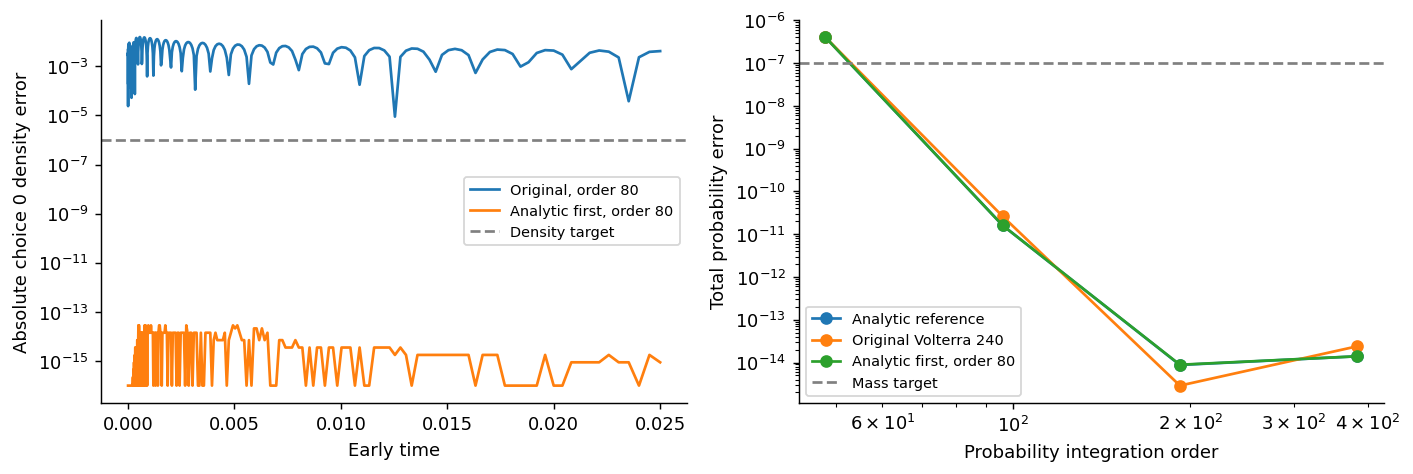

In [11]:
# Compare both implementations with the same, refined probability integration.
comparison_rows = [accuracy_row("Near boundary", near_specs, "Volterra", order, bin_order=192)
                   for order in [80, 240]]
comparison_rows.append(accuracy_row("Near boundary", near_specs, improved_method, 80, bin_order=192))
comparison = pd.DataFrame(comparison_rows)
columns = ["method", "order", "bin_order", "max_density_error", "max_cdf_error",
           "max_bin_error", "mass_error", "min_density", "largest_cdf_drop", "meets_targets"]
display(comparison[columns])

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
early = np.geomspace(1e-6, .025, 500)
truth = race_density(*exact_marginals(near_specs, early))[:, 0]
for method, label in [("Volterra", "Original, order 80"),
                      (improved_method, "Analytic first, order 80")]:
    predicted = race_density(*build_model(near_specs, method, 80).marginals(early))[:, 0]
    axes[0].semilogy(early, np.maximum(abs(predicted-truth), 1e-16), label=label)
axes[0].axhline(1e-6, color="grey", ls="--", label="Density target")
axes[0].set(xlabel="Early time", ylabel="Absolute choice 0 density error")
for label, group in integration_check.groupby("method", sort=False):
    axes[1].loglog(group.bin_order, np.maximum(group.mass_error, 1e-16), "o-", label=label)
axes[1].axhline(1e-7, color="grey", ls="--", label="Mass target")
axes[1].set(xlabel="Probability integration order", ylabel="Total probability error")
for ax in axes:
    ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

### Does the improvement work in other cases?

We run the improved method on nine cases with known answers, then place runner 0 at four distances below its boundary: 0.10, 0.05, 0.02, and 0.01. We use the same six pass criteria throughout to see whether the improvement holds beyond the original example.

In [12]:
improved_accuracy = pd.DataFrame([
    accuracy_row(name, specs, improved_method, 80, bin_order=192)
    for name, specs in cases.items()
])
display(improved_accuracy[["case", "max_density_error", "max_cdf_error", "mass_error", "meets_targets"]])

gap_rows = []
for gap in [.1, .05, .02, .01]:
    specs = deepcopy(near_specs)
    specs[0]["x0"] = specs[0]["boundary0"] - gap
    row = accuracy_row(f"Gap {gap:g}", specs, improved_method, 80, bin_order=192)
    candidate = build_model(specs, improved_method, 80)
    _, coarse_bins, coarse_omission = probability_bins(specs, candidate, order=192)
    _, fine_bins, fine_omission = probability_bins(specs, candidate, order=384)
    row.update(gap=gap, bin_refinement_change=float(abs(coarse_bins-fine_bins).max()),
               refined_mass_error=abs(fine_bins.sum()+fine_omission-1))
    gap_rows.append(row)
gap_accuracy = pd.DataFrame(gap_rows)
display(gap_accuracy[["gap", "max_density_error", "max_cdf_error", "mass_error",
                      "bin_refinement_change", "refined_mass_error", "meets_targets"]])
assert improved_accuracy.meets_targets.all()
assert gap_accuracy.meets_targets.all()
assert gap_accuracy.bin_refinement_change.max() < 1e-9
assert gap_accuracy.refined_mass_error.max() < 1e-9
print(f"Analytic first, order 80: {improved_accuracy.meets_targets.sum()}/9 analytic cases and "
      f"{gap_accuracy.meets_targets.sum()}/4 tested boundary gaps pass.")

Analytic first, order 80: 9/9 analytic cases and 4/4 tested boundary gaps pass.


,case,max_density_error,max_cdf_error,mass_error,meets_targets
0,1 stage,1.110223e-16,0.000000e+00,2.220446e-16,True
1,5 stages,4.163336e-16,9.992007e-16,9.992007e-16,True
2,10 stages,4.440892e-16,1.221245e-15,9.992007e-16,True
3,20 stages,5.551115e-16,9.992007e-16,8.881784e-16,True
4,Short first,5.551115e-16,1.110223e-15,8.881784e-16,True
5,Short middle,4.163336e-16,1.110223e-15,1.221245e-15,True
6,Negative drift,3.885781e-16,7.771561e-16,6.661338e-16,True
7,Near boundary,1.421085e-14,7.771561e-16,8.881784e-15,True
8,Varying parameters,3.885781e-16,8.326673e-16,4.440892e-16,True


,gap,max_density_error,max_cdf_error,mass_error,bin_refinement_change,refined_mass_error,meets_targets
0,0.10,1.776357e-14,7.771561e-16,7.438494e-15,1.887379e-14,1.221245e-14,True
1,0.05,1.421085e-14,7.771561e-16,8.881784e-15,2.242651e-14,1.398881e-14,True
2,0.02,1.250555e-12,7.771561e-16,2.553513e-15,2.287059e-14,2.065015e-14,True
3,0.01,2.273737e-12,7.771561e-16,3.738099e-11,3.734768e-11,3.330669e-14,True


All nine known-answer cases and all four starting distances pass. A more precise probability calculation barely changes those results.

The **Near boundary** case keeps drift, noise, and boundary slope fixed across stages. **Varying parameters** changes them in a special way that still lets us calculate the exact answer. The final case combines a start 0.05 below the boundary with stage changes that do not follow that pattern. We do not know its exact answer, so close agreement between finer Volterra runs and Centered checks consistency, not the true error.

In [13]:
heterogeneous_specs = deepcopy(specifications("B"))
heterogeneous_specs[0]["x0"] = heterogeneous_specs[0]["boundary0"] - .05
grid = time_grid(heterogeneous_specs)
base = build_model(heterogeneous_specs, improved_method, 80)
base_f, base_F = base.marginals(grid)
heterogeneous_rows = []
for label, candidate in [
    ("Volterra interpolation 80 to 120", build_model(heterogeneous_specs, improved_method, 120)),
    ("Tighter history integral", build_model(heterogeneous_specs, improved_method, 80,
                                           passage_atol=1e-12, passage_rtol=1e-10)),
    ("Independent centered quadrature, order 120", build_model(heterogeneous_specs, "Centered", 120)),
]:
    f, F = candidate.marginals(grid)
    heterogeneous_rows.append(dict(check=label, max_density_difference=float(abs(f-base_f).max()),
                                    max_cdf_difference=float(abs(F-base_F).max())))
heterogeneous_check = pd.DataFrame(heterogeneous_rows)
display(heterogeneous_check)
assert heterogeneous_check.max_density_difference.max() < 1e-6
assert heterogeneous_check.max_cdf_difference.max() < 1e-7

output = save_results("01_analytic_first", {
    "integration_convergence": integration_check, "near_boundary_comparison": comparison,
    "all_analytic_cases": improved_accuracy, "boundary_gaps": gap_accuracy,
    "heterogeneous_consistency": heterogeneous_check,
    "heterogeneous_parameters": parameter_table(heterogeneous_specs),
}, {"method": improved_method, "interpolation_order": 80, "probability_integration_order": 192,
    "integration_refinement_order": 384, "boundary_gaps": [.1, .05, .02, .01],
    "density_target": 1e-6, "probability_target": 1e-7, "negative_density_tolerance": 1e-10,
    "cdf_drop_tolerance": 1e-10, "integration_refinement_target": 1e-9})
print("Saved improvement checks:", output.relative_to(root))

Saved improvement checks: examples/example6_race_model/results/01_analytic_first


,check,max_density_difference,max_cdf_difference
0,Volterra interpolation 80 to 120,6.439294e-14,8.881784e-16
1,Tighter history integral,2.209344e-14,6.106227e-15
2,"Independent centered quadrature, order 120",3.825927e-10,1.199041e-14
